In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Average latencies (example values in milliseconds)
#  the between stage time includes queueing
# vortex_avg_
sys_name="Vortex"
# avg
# latencies = {
#     "d-A":4.661,
#     "d-B":1.686,
#     "stepA": 18.993,
#     "stepB": 30.854,
#     "A-C": 7.629,
#     "B-C": 4.829,
#     "stepC": 5.410,
#     "C-D": 1.329,
#     "stepD": 24.536
# }

# one plot
# latencies = {
#     "d-A":4.661,
#     "d-B":1.686,
#     "stepA": 22.916,
#     "stepB": 30.969,
#     "A-C": 8.336,
#     "B-C": 3.414,
#     "stepC": 5.108,
#     "C-D": 1.329,
#     "stepD": 25.043
# }

# sys_name="Ray"
# # ray_avg_
latencies = {
    "stepA": 13.19,
    "stepB": 48.13,
    "A-C": 13,
    "B-C": 13,
    "stepC": 11.05,
    "C-D": 30,
    "stepD": 63.38
}

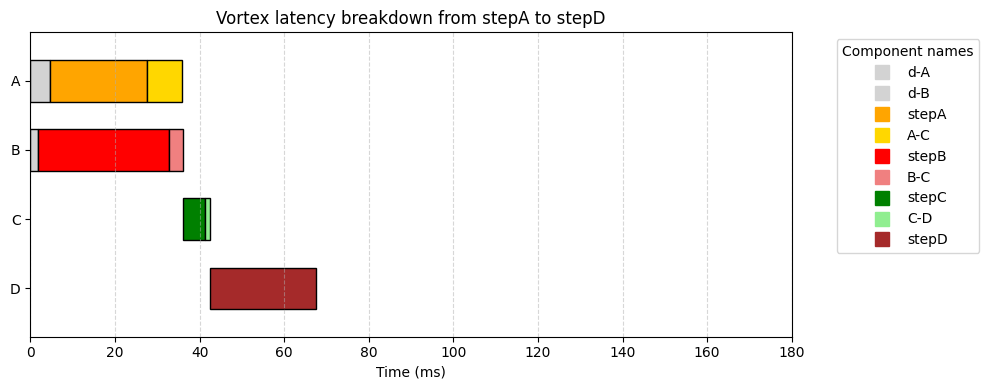

In [67]:
# Define execution lines
line1 = [
    ("d-A", 0),
    ("stepA", latencies["d-A"]),
    ("A-C", latencies["d-A"] + latencies["stepA"])
]
line2 = [
    ("d-B", 0),
    ("stepB", latencies["d-B"]),
    ("B-C", latencies["d-B"] + latencies["stepB"])
]

# Determine when stepC can start (after both A->C and B->C are complete)
stepC_start = max(
    latencies["d-A"] + latencies["stepA"] + latencies["A-C"],
    latencies["d-B"] + latencies["stepB"] + latencies["B-C"]
)

line3 = [
    ("stepC", stepC_start),
    ("C-D", stepC_start + latencies["stepC"]),
    ("stepD", stepC_start + latencies["stepC"] + latencies["C-D"])
]

# Assign distinct colors to each step
color_map = {
    "d-A": "lightgray",
    "d-B": "lightgray",
    "stepA": "orange",
    "A-C": "gold",
    "stepB": "red",
    "B-C": "lightcoral",
    "stepC": "green",
    "C-D": "lightgreen",
    "stepD": "brown"
}

# Y-axis level mapping
y_levels = {
    "d-A": 4,
    "stepA": 4,
    "A-C": 4,
    "d-B": 3,
    "stepB": 3,
    "B-C": 3,
    "stepC": 2,
    "C-D": 2,
    "stepD": 1
}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 4))

# Function to draw bars
def plot_bars_custom(line):
    for step, start_time in line:
        duration = latencies[step]
        y_level = y_levels[step]
        ax.add_patch(
            patches.Rectangle(
                (start_time, y_level - 0.3), duration, 0.6,
                edgecolor='black', facecolor=color_map[step], label=step
            )
        )

# Plot all lines
plot_bars_custom(line1)
plot_bars_custom(line2)
plot_bars_custom(line3)

# Create legend handles (no duplicates)
handles = []
for step, color in color_map.items():
    handles.append(
        mlines.Line2D([], [], color=color, marker='s',
                      linestyle='None', markersize=10, label=step)
    )

# Set axis properties
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['D', 'C', 'B', 'A'])
ax.set_xlabel("Time (ms)")
ax.set_title(f"{sys_name} latency breakdown from stepA to stepD")
ax.set_xlim(0, 180)
ax.set_ylim(0.3, 4.7)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# Add legend
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Component names")

# Save and display
plt.tight_layout()
plt.savefig(f"{sys_name}_latency_breakdown.pdf", dpi=300, bbox_inches='tight')
plt.show()


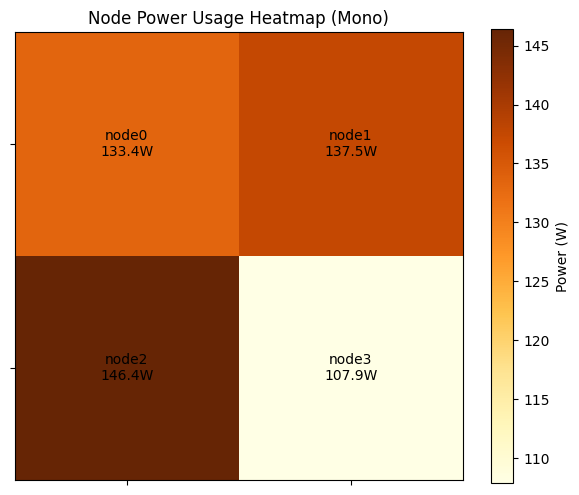

In [73]:
# Define power usage for each node (replace with actual values as needed)
deployment_type = "Mono"
power_usage = {
    "node0": 133.38,
    "node1": 137.50,
    "node2": 146.40,
    "node3": 107.87
}

# power_usage = {
#     "node0": 128.5,
#     "node1": 130.2,
#     "node2": 131.7,
#     "node3": 129.4
# }

power_grid = np.array([
    [power_usage["node0"], power_usage["node1"]],
    [power_usage["node2"], power_usage["node3"]]
])

# Plot the heatmap
fig, ax = plt.subplots(figsize=(6, 5))
heatmap = ax.imshow(power_grid, cmap='YlOrBr', interpolation='nearest')

# Annotate each cell with node name and power usage
node_labels = [["node0", "node1"], ["node2", "node3"]]
for i in range(2):
    for j in range(2):
        label = f"{node_labels[i][j]}\n{power_grid[i, j]:.1f}W"
        ax.text(j, i, label, ha='center', va='center', color='black', fontsize=10)

# Remove axis labels and ticks
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([])
ax.set_yticklabels([])

# Add title and colorbar
ax.set_title(f"Node Power Usage Heatmap ({deployment_type})")
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("Power (W)")

# Final layout
plt.tight_layout()
plt.savefig(f"{sys_name}_power_usage_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/5m/0xdx3r_57y541knfgfck0b3m0000gn/T/ipykernel_12108/694306056.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


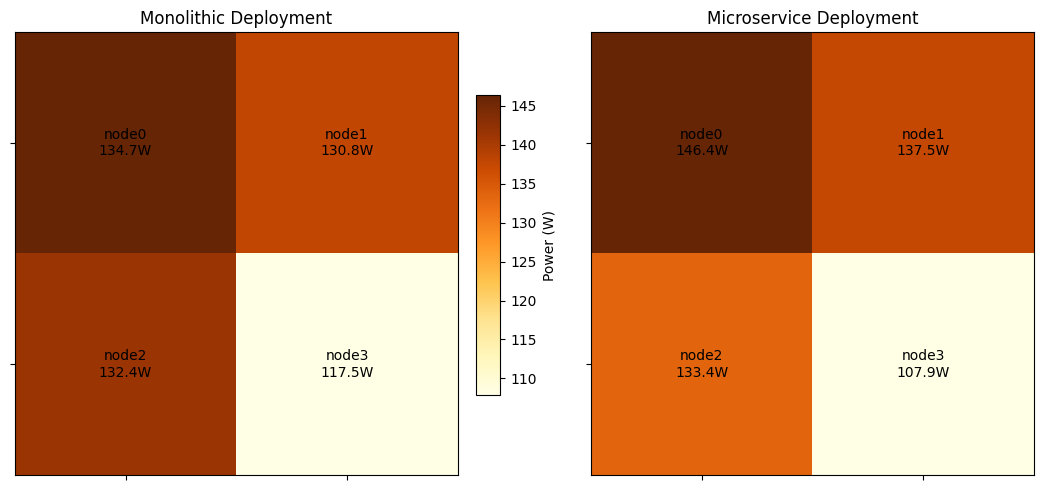

In [76]:
# Example power usage for two deployment strategies
monolithic_power = {
    "node0": 134.66,
    "node1": 130.81,
    "node2": 132.39,
    "node3": 117.48
}

microservice_power = {
    "node0": 146.40,
    "node1": 137.50,
    "node2": 133.38,
    "node3": 107.87
}

# Arrange power data into 2x2 grids
monolithic_grid = np.array([
    [monolithic_power["node0"], monolithic_power["node1"]],
    [monolithic_power["node2"], monolithic_power["node3"]]
])

microservice_grid = np.array([
    [microservice_power["node0"], microservice_power["node1"]],
    [microservice_power["node2"], microservice_power["node3"]]
])

# Node labels for annotations
node_labels = [["node0", "node1"], ["node2", "node3"]]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Titles and data for each subplot
titles = ["Monolithic Deployment", "Microservice Deployment"]
grids = [monolithic_grid, microservice_grid]

# Draw each heatmap
for idx, ax in enumerate(axes):
    heatmap = ax.imshow(grids[idx], cmap='YlOrBr', interpolation='nearest')
    for i in range(2):
        for j in range(2):
            label = f"{node_labels[i][j]}\n{grids[idx][i, j]:.1f}W"
            ax.text(j, i, label, ha='center', va='center', color='black', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(titles[idx])

# Shared vertical colorbar centered between the plots
# [left, bottom, width, height] coordinates
cbar_ax = fig.add_axes([0.46, 0.2, 0.02, 0.6])  # Adjust as needed
cbar = plt.colorbar(heatmap, cax=cbar_ax)
cbar.set_label("Power (W)")

# Layout and display
plt.tight_layout()
plt.savefig(f"deployment_power.pdf", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/5m/0xdx3r_57y541knfgfck0b3m0000gn/T/ipykernel_12108/2296682486.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


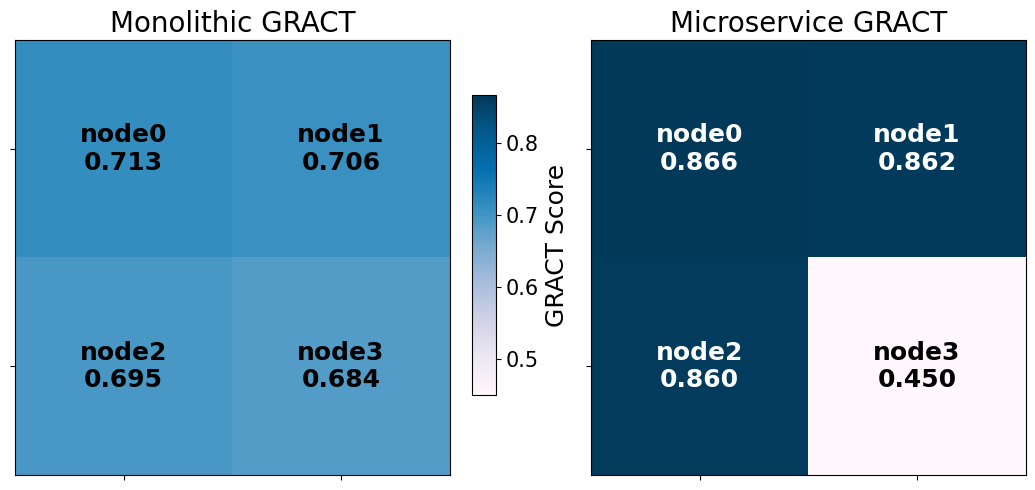

In [92]:
# GRACT values at high load (105 SR)
monolithic_gract = {
    "node0": 0.713,
    "node1": 0.706,
    "node2": 0.695,
    "node3": 0.684
}

microservice_gract = {
    "node0": 0.866,
    "node1": 0.862,
    "node2": 0.860,
    "node3": 0.450
}

# Arrange into 2x2 grids
monolithic_gract_grid = np.array([
    [monolithic_gract["node0"], monolithic_gract["node1"]],
    [monolithic_gract["node2"], monolithic_gract["node3"]]
])

microservice_gract_grid = np.array([
    [microservice_gract["node0"], microservice_gract["node1"]],
    [microservice_gract["node2"], microservice_gract["node3"]]
])

# Combine all values for shared color scale
all_values = np.concatenate([monolithic_gract_grid.flatten(), microservice_gract_grid.flatten()])
vmin, vmax = np.min(all_values), np.max(all_values)

# Node labels
node_labels = [["node0", "node1"], ["node2", "node3"]]

# Set up the plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = ["Monolithic GRACT", "Microservice GRACT"]
grids = [monolithic_gract_grid, microservice_gract_grid]

# Plot each heatmap
for idx, ax in enumerate(axes):
    grid = grids[idx]
    heatmap = ax.imshow(grid, cmap='PuBu', interpolation='nearest', vmin=vmin, vmax=vmax)

    # Annotate with adaptive text color and larger font
    for i in range(2):
        for j in range(2):
            val = grid[i, j]
            text_color = 'white' if val >= 0.8 else 'black'
            label = f"{node_labels[i][j]}\n{val:.3f}"
            ax.text(j, i, label, ha='center', va='center', color=text_color, fontsize=18, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(titles[idx], fontsize=20)

# Add shared vertical colorbar between plots
cbar_ax = fig.add_axes([0.46, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = plt.colorbar(heatmap, cax=cbar_ax)
cbar.set_label("GRACT Score", fontsize=18)
cbar.ax.tick_params(labelsize=15)  
# Save and display
plt.tight_layout()
plt.savefig("deployment_gract.pdf", dpi=300, bbox_inches='tight')
plt.show()